Step 1 - Load dataset runtime: 0.02500 seconds
Data types of columns:
Domain           object
Have_IP           int64
Have_At           int64
URL_Length        int64
URL_Depth         int64
Redirection       int64
https_Domain      int64
TinyURL           int64
Prefix/Suffix     int64
DNS_Record        int64
Web_Traffic       int64
Domain_Age        int64
Domain_End        int64
iFrame            int64
Mouse_Over        int64
Right_Click       int64
Web_Forwards      int64
Label             int64
dtype: object
Step 2 - Data preprocessing runtime: 0.00901 seconds
Step 3 - Train-test split runtime: 0.00200 seconds
Before SMOTE: Class distribution in y_train: 1    4012
0    3988
dtype: int64
After SMOTE: Class distribution in y_train_resampled: 1    4012
0    4012
dtype: int64
Step 4 - SMOTE runtime: 0.42802 seconds
Step 5 - Model training runtime: 0.43225 seconds
Step 6 - Prediction and evaluation runtime: 0.04851 seconds
Random Forest Accuracy: 0.958
Random Forest ROC-AUC: 0.99493577075

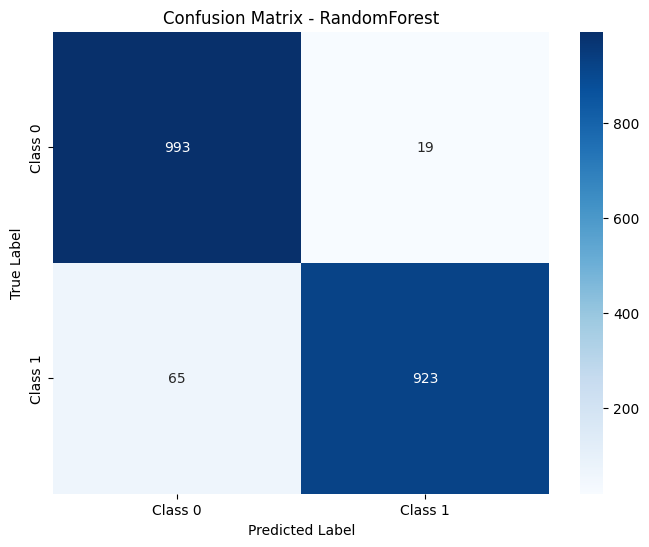

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

# Set the logical cores count for parallelism (if needed)
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

# Track overall runtime
overall_start_time = time.time()

# Define dataset and model information
dataset_name = "ds_10k18"
model_name = "RandomForest"

# Step 1: Load dataset
step_start_time = time.time()
df = pd.read_csv(f"{dataset_name}.csv")
step_end_time = time.time()
print(f"Step 1 - Load dataset runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 2: Data preprocessing
step_start_time = time.time()
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Map class labels if necessary to ensure they are 0 and 1
y = np.where(y == -1, 0, y)
step_end_time = time.time()
print(f"Step 2 - Data preprocessing runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 3: Split the data into training and testing sets
step_start_time = time.time()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
step_end_time = time.time()
print(f"Step 3 - Train-test split runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 4: Handle imbalance in target using SMOTE
step_start_time = time.time()
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)
print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())
step_end_time = time.time()
print(f"Step 4 - SMOTE runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 5: Train Random Forest model
step_start_time = time.time()
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
step_end_time = time.time()
print(f"Step 5 - Model training runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 6: Predict and evaluate model
step_start_time = time.time()
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculate performance metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

false_positive_rate = conf_matrix[0, 1] / conf_matrix[0].sum()

step_end_time = time.time()
print(f"Step 6 - Prediction and evaluation runtime: {step_end_time - step_start_time:.5f} seconds")

print(f"Random Forest Accuracy: {rf_accuracy}")
print(f"Random Forest ROC-AUC: {rf_roc_auc}")
print(f"False Positive Rate: {false_positive_rate}")
print(f"Confusion Matrix:\n{conf_matrix}")

# Save confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title(f'Confusion Matrix - {model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
#plt.savefig(f"{dataset_name}_{model_name}_confusion_matrix.png")
plt.show()



In [18]:
# Step 7: SHAP Analysis
step_start_time = time.time()
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

#if isinstance(shap_values, list) and len(shap_values) > 1:
#    shap_values = shap_values[1]



<Figure size 640x480 with 0 Axes>

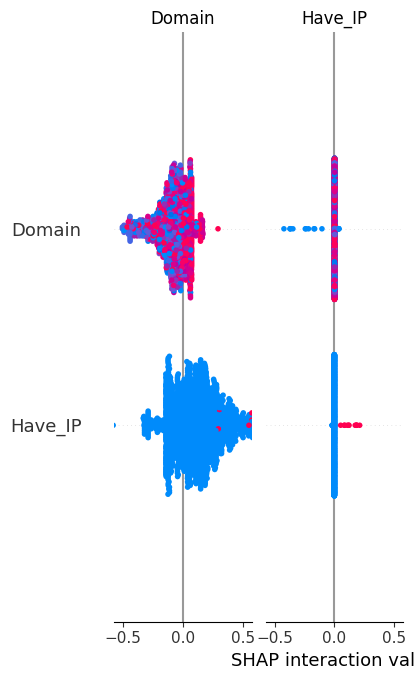

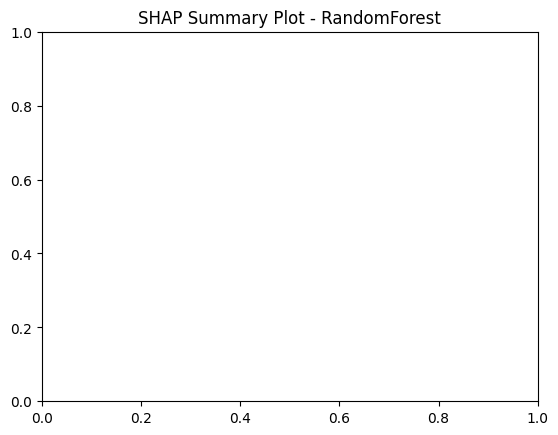

In [27]:
# Save SHAP summary plot


plt.figure()
#shap.summary_plot(shap_values_class_1, features=X_test.values, feature_names=X_test.columns)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)
plt.title(f"SHAP Summary Plot - {model_name}")
#plt.savefig(f"{dataset_name}_{model_name}_shap_summary_plot.png")
plt.show()


In [15]:
# Save SHAP feature importance plot
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="bar")
plt.title(f"SHAP Feature Importance - {model_name}")
#plt.savefig(f"{dataset_name}_{model_name}_shap_feature_importance.png")
plt.show()



AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

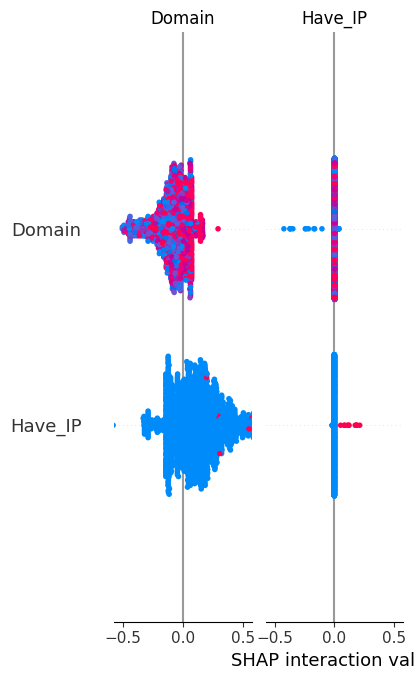

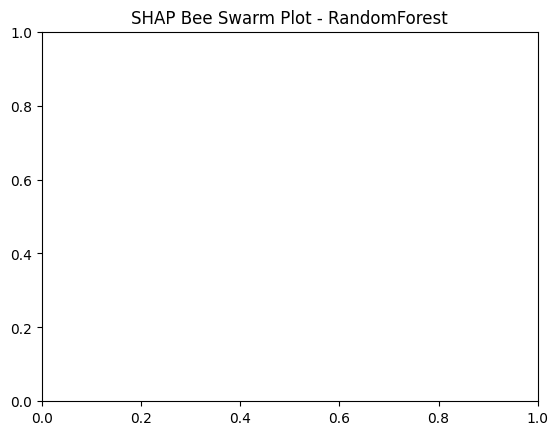

Step 7 - SHAP analysis runtime: 377.89627 seconds


In [9]:
# Save SHAP bee swarm plot
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="violin")
plt.title(f"SHAP Bee Swarm Plot - {model_name}")
#plt.savefig(f"{dataset_name}_{model_name}_shap_bee_swarm.png")
plt.show()

step_end_time = time.time()
print(f"Step 7 - SHAP analysis runtime: {step_end_time - step_start_time:.5f} seconds")



In [10]:
# Step 8: Create new features from SHAP values and predicted labels
step_start_time = time.time()
X_test['predicted_label'] = y_pred
for i, feature in enumerate(X.columns):
    X_test[f'shap_{feature}'] = shap_values[:, i]
X_test.to_csv(f"{dataset_name}_with_predictions_and_shap.csv", index=False)
step_end_time = time.time()
print(f"Step 8 - New feature creation runtime: {step_end_time - step_start_time:.5f} seconds")

# Overall runtime
overall_end_time = time.time()
print(f"Overall runtime: {overall_end_time - overall_start_time:.5f} seconds")


ValueError: Expected a 1D array, got an array with shape (2000, 2)